In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:

from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
import pandas as pd

df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
## data cleaning
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

In [ ]:
## Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
# Fill missing values

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


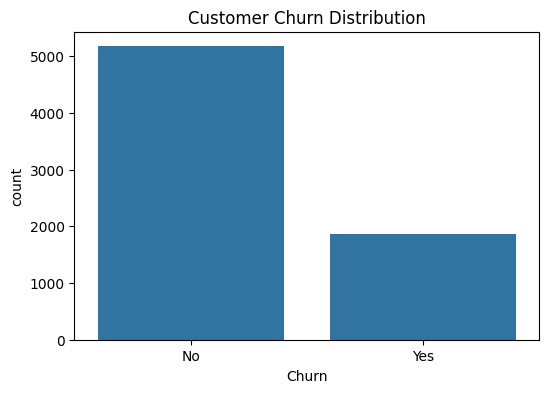

In [ ]:
# Exploratory Data Analysis (EDA)
# Churn Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

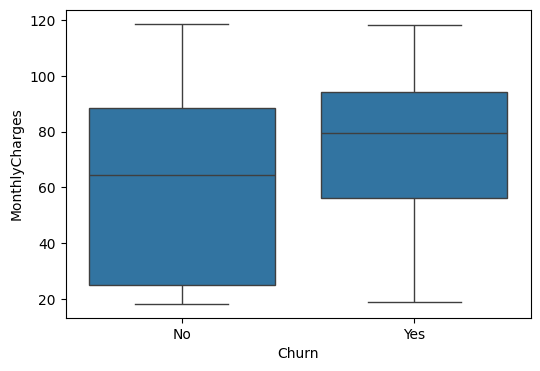

In [ ]:
# Monthly Charges vs Churn
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

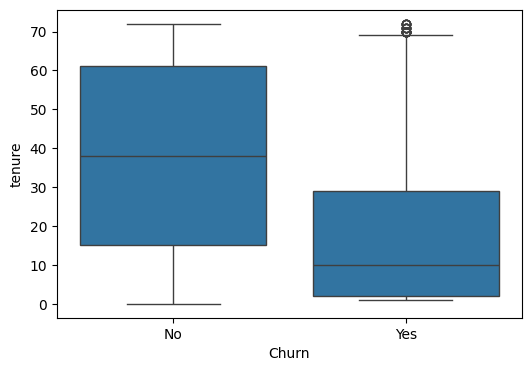

In [ ]:
# Tenure vs Churn
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.show()

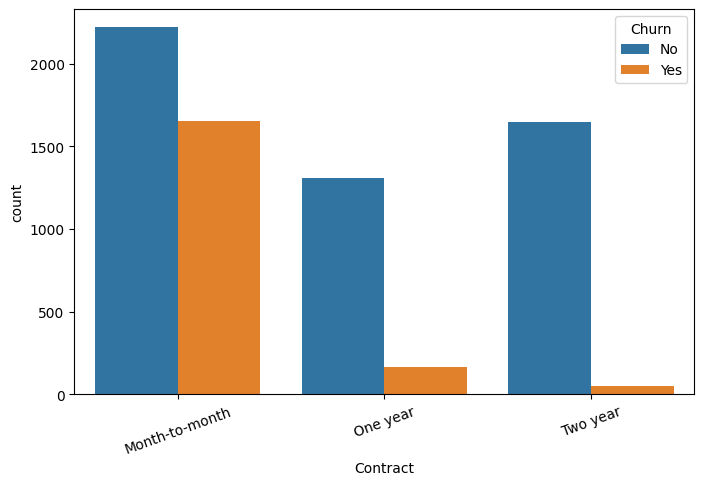

In [ ]:
# Contract Type vs Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=20)
plt.show()

In [ ]:
# Convert Target Variable
df["Churn"] = df["Churn"].map(
    {
        "Yes":1,
        "No":0
    }
)

In [ ]:
# Encode Categorical Features

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [ ]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
#  Split Features and Target

X = df_encoded.drop(
    "Churn",
    axis=1
)

y = df_encoded["Churn"]

In [ ]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
# Logistic Regression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Recall:",
    recall_score(y_test, lr_pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, lr_pred)
)

Accuracy: 0.8211497515968772
Recall: 0.6005361930294906
ROC AUC: 0.7505576718043206


In [ ]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Recall:",
    recall_score(y_test, rf_pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, rf_pred)
)

Accuracy: 0.7934705464868701
Recall: 0.46112600536193027
ROC AUC: 0.6871267092446716


In [ ]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

print(
    "Recall:",
    recall_score(y_test, xgb_pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, xgb_pred)
)

Accuracy: 0.8048261178140526
Recall: 0.5415549597855228
ROC AUC: 0.7205844296997111


In [ ]:
# Compare Models

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "ROC-AUC":[
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, rf_pred),
        roc_auc_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.821150,0.600536,0.750558
1,Random Forest,0.793471,0.461126,0.687127
2,XGBoost,0.804826,0.541555,0.720584


In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

In [ ]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

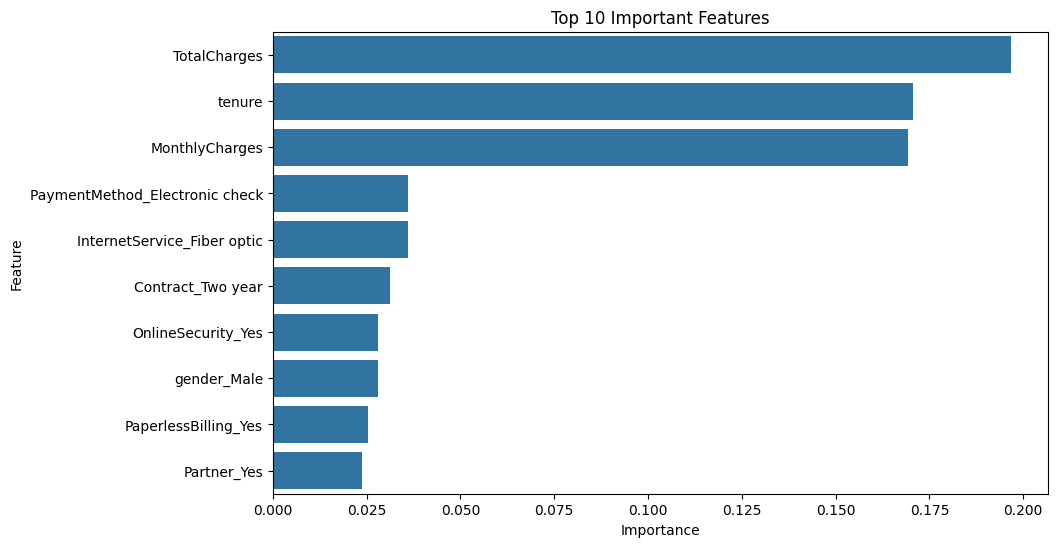

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [ ]:
# Save Best Model

import joblib

joblib.dump(
    rf,
    "customer_churn_model.pkl"
)

['customer_churn_model.pkl']

In [ ]:
from google.colab import files

files.download(
    "customer_churn_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>